<div style="background: linear-gradient(135deg, #1A1A2E 0%, #2C3E5C 100%); color: white; padding: 30px; border-left: 10px solid #E67E22; border-radius: 0 6px 6px 0; margin-bottom: 20px;">
<div style="color: #FCE4CD; font-size: 13px; font-weight: bold; letter-spacing: 2px;"> &mdash; </div>
<h1 style="margin: 8px 0 0 0; color: white; font-size: 32px;">Used Car Price Predicition </h1>
<div style="color: #FCE4CD; font-style: italic; margin-top: 10px; font-size: 14px;"></div>
</div>


| Field | Value |
|-------|-------|
 |
| Members | *Nawaf Alsnaidi , Osama Alkhudiri , Abdulaziz AbuHaiemd , Rayan Almahmoud * |
| Chosen Dataset | *Saudi Used Cars Market* |
| Research Question | *Can used car prices in Saudi Arabia be predicted based on features such as brand, model, car age,and mileage?* |
| Target Variable (Y) | *Price (SAR)* |

---



In [3]:
# Core data libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# For detailed regression output with p-values and diagnostics (Chapter 6-7)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Make output deterministic
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup complete. All libraries imported.")

Setup complete. All libraries imported.


In [8]:
DATA_PATH = "Used_car_CSV.csv"

# Load the data
df = pd.read_csv(DATA_PATH,sep=";")

# Inspect shape and structure
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn names:\n{list(df.columns)}")
df.head()

Dataset shape: 8,035 rows x 13 columns

Column names:
['Make', 'Type', 'Year', 'Origin', 'Color', 'Options', 'Engine_Size', 'Fuel_Type', 'Gear_Type', 'Mileage', 'Region', 'Price', 'Negotiable']


,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
0,Chrysler,C300,2018,Saudi,Black,Full,5.7,Gas,Automatic,103000,Riyadh,114000,False
1,Nissan,Patrol,2016,Saudi,White,Full,4.8,Gas,Automatic,5448,Riyadh,0,True
2,Nissan,Sunny,2019,Saudi,Silver,Standard,1.5,Gas,Automatic,72418,Riyadh,27500,False
3,Hyundai,Elantra,2019,Saudi,Grey,Standard,1.6,Gas,Automatic,114154,Riyadh,43000,False
4,Hyundai,Elantra,2019,Saudi,Silver,Semi Full,2.0,Gas,Automatic,41912,Riyadh,59500,False


In [9]:
# Column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8035 entries, 0 to 8034
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Make         8035 non-null   object 
 1   Type         8035 non-null   object 
 2   Year         8035 non-null   int64  
 3   Origin       8035 non-null   object 
 4   Color        8035 non-null   object 
 5   Options      8035 non-null   object 
 6   Engine_Size  8035 non-null   float64
 7   Fuel_Type    8035 non-null   object 
 8   Gear_Type    8035 non-null   object 
 9   Mileage      8035 non-null   int64  
 10  Region       8035 non-null   object 
 11  Price        8035 non-null   int64  
 12  Negotiable   8035 non-null   bool   
dtypes: bool(1), float64(1), int64(3), object(8)
memory usage: 761.3+ KB


In [10]:
# Quick summary statistics for numeric columns
df.describe()

,Year,Engine_Size,Mileage,Price
count,8035.000000,8035.000000,8.035000e+03,8.035000e+03
mean,2014.097698,3.287729,1.491488e+05,5.369984e+04
std,5.757228,1.517747,3.474480e+05,7.198472e+04
min,1963.000000,1.000000,1.000000e+02,0.000000e+00
25%,2012.000000,2.000000,3.700000e+04,0.000000e+00
50%,2016.000000,3.000000,1.019600e+05,3.700000e+04
75%,2018.000000,4.400000,1.950000e+05,7.375000e+04
max,2022.000000,9.000000,2.000000e+07,1.150000e+06


In [11]:
# Check how many missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing": missing, "pct": missing_pct})
missing_df = missing_df[missing_df["missing"] > 0].sort_values("missing", ascending=False)
print("Columns with missing values:")
missing_df

Columns with missing values:


,missing,pct


In [12]:
# No missing values were found in the dataset.
# Therefore, no rows were dropped and no imputation was required.

print(f"Rows remaining after missing-value check: {len(df):,}")

Rows remaining after missing-value check: 8,035


clean

In [13]:
# Create cleaned dataset
df_clean = df.copy()

# Remove invalid prices
df_clean = df_clean[df_clean["Price"] > 0]

# Keep realistic mileage values
df_clean = df_clean[df_clean["Mileage"] >= 0]
df_clean = df_clean[df_clean["Mileage"] <= 1000000]

# Keep realistic manufacturing years
df_clean = df_clean[df_clean["Year"] >= 1990]
df_clean = df_clean[df_clean["Year"] <= 2025]

# Create Car_Age feature
df_clean["Car_Age"] = 2026 - df_clean["Year"]

print("Original dataset size:", df.shape)
print("Final dataset size after filtering:", df_clean.shape)
print("Rows removed:", df.shape[0] - df_clean.shape[0])

Original dataset size: (8035, 13)
Final dataset size after filtering: (5462, 14)
Rows removed: 2573


In [14]:
# Identify categorical columns
cat_cols = df_clean.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
print(f"Categorical columns: {cat_cols}")

# Apply one-hot encoding to categorical variables
df_encoded = pd.get_dummies(
    df_clean,
    columns=cat_cols,
    drop_first=True
)

print("Shape before encoding:", df_clean.shape)
print("Shape after encoding:", df_encoded.shape)

df_encoded.head()

Categorical columns: ['Make', 'Type', 'Origin', 'Color', 'Options', 'Fuel_Type', 'Gear_Type', 'Region', 'Negotiable']
Shape before encoding: (5462, 14)
Shape after encoding: (5462, 456)


,Year,Engine_Size,Mileage,Price,Car_Age,Make_Audi,Make_BMW,Make_BYD,Make_Bentley,Make_Cadillac,...,Region_Najran,Region_Qassim,Region_Qurayyat,Region_Riyadh,Region_Sabya,Region_Sakaka,Region_Tabouk,Region_Taef,Region_Wadi Dawasir,Region_Yanbu
0,2018,5.7,103000,114000,8,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,2019,1.5,72418,27500,7,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,2019,1.6,114154,43000,7,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,2019,2.0,41912,59500,7,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
5,2018,1.5,39000,72000,8,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [15]:
# Create a new feature for car age
df_clean["Car_Age"] = 2026 - df_clean["Year"]

df_clean[["Year", "Car_Age"]].head()

,Year,Car_Age
0,2018,8
2,2019,7
3,2019,7
4,2019,7
5,2018,8




### 4.1 Distribution of the Target Variable

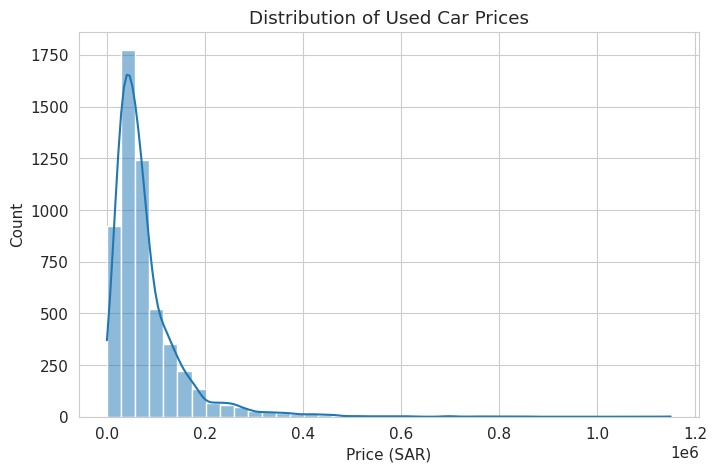

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["Price"], bins=40, kde=True)
plt.title("Distribution of Used Car Prices")
plt.xlabel("Price (SAR)")
plt.ylabel("Count")
plt.show()

4.2 Relationship Between Car Age and Price

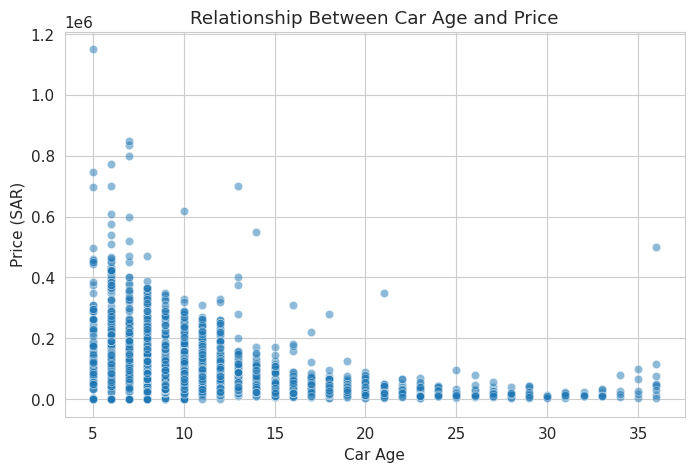

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x="Car_Age", y="Price", alpha=0.5)
plt.title("Relationship Between Car Age and Price")
plt.xlabel("Car Age")
plt.ylabel("Price (SAR)")
plt.show()

4.3 Relationship Between Mileage and Price

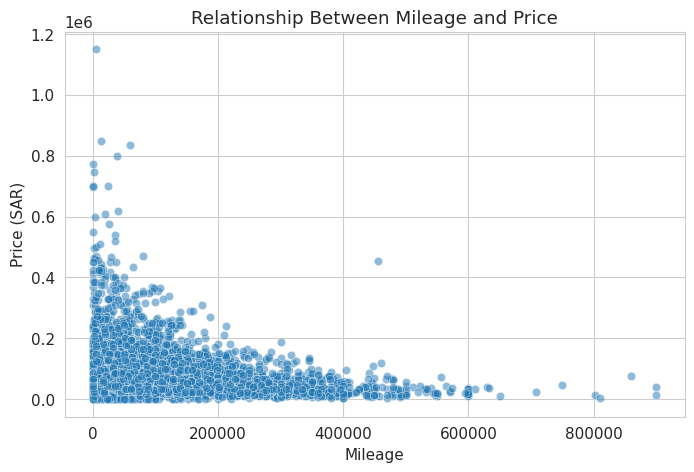

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x="Mileage", y="Price", alpha=0.5)
plt.title("Relationship Between Mileage and Price")
plt.xlabel("Mileage")
plt.ylabel("Price (SAR)")
plt.show()

4.4 Price by Gear Type

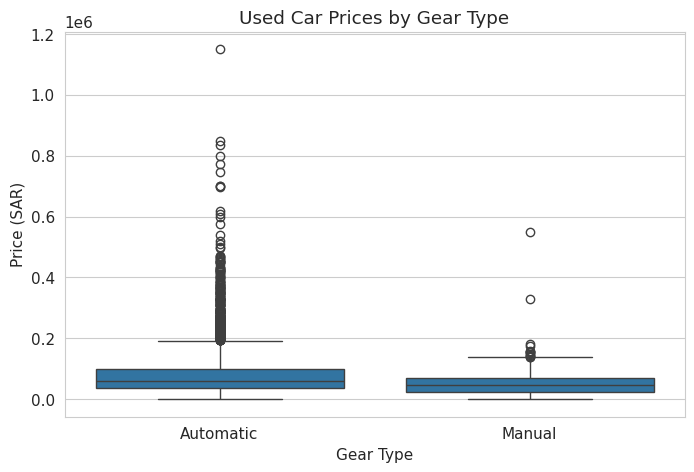

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x="Gear_Type", y="Price")
plt.title("Used Car Prices by Gear Type")
plt.xlabel("Gear Type")
plt.ylabel("Price (SAR)")
plt.show()

4.5 Correlation Matrix of Numeric Variables

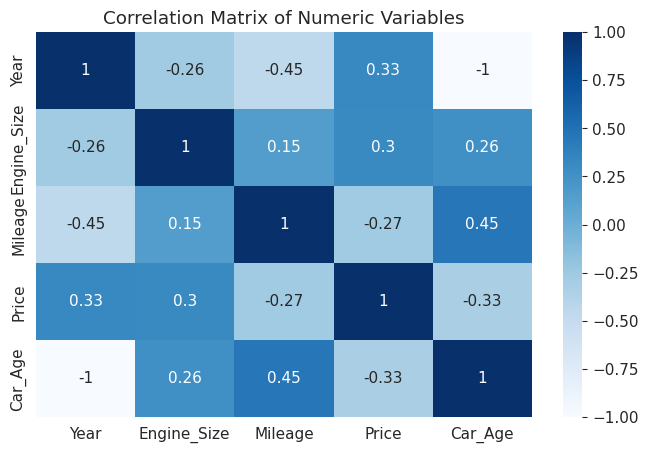

In [20]:
numeric_cols = ["Year", "Engine_Size", "Mileage", "Price", "Car_Age"]

corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Matrix of Numeric Variables")
plt.show()


### 4.3 Correlation Heatmap

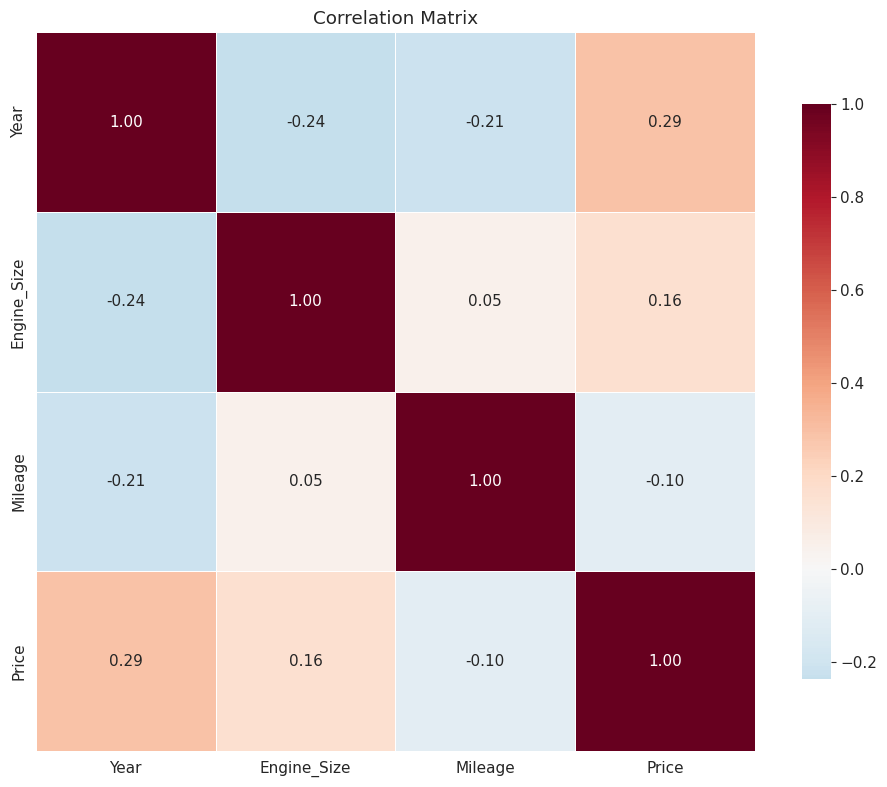

In [21]:
# Correlation matrix of all numeric columns
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [22]:
# Define features X and target y

X = df_encoded.drop(columns=["Price", "Year"])  # Year removed because Car_Age already represents it
y = df_encoded["Price"]

# Train/test split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")

Training set: 4,369 rows
Test set:     1,093 rows


In [23]:
# Fit Linear Regression with scikit-learn
model = LinearRegression()
model.fit(X_train, y_train)

# Coefficients
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": model.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print(f"Intercept: {model.intercept_:.4f}")
print("\nCoefficients (sorted by absolute magnitude):")
coef_df.head(15)

Intercept: 233896.8933

Coefficients (sorted by absolute magnitude):


,feature,coefficient
382,Type_Vantage,430605.296215
6,Make_Bentley,362412.105884
51,Make_Rolls-Royce,337697.255812
206,Type_G,335387.120069
98,Type_Bentayga,328727.296007
381,Type_Vanquish,291137.668687
87,Type_Arnage,263196.512949
127,Type_Camargue,238790.669673
201,Type_Flying Spur,-229511.703072
70,Type_911,182384.132326



### 6.1 Performance Metrics

In [24]:
# Predictions on train and test
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Metrics
results = pd.DataFrame({
    "Metric": ["R-squared", "RMSE", "MAE"],
    "Training": [
        r2_score(y_train, y_pred_train),
        np.sqrt(mean_squared_error(y_train, y_pred_train)),
        mean_absolute_error(y_train, y_pred_train),
    ],
    "Test": [
        r2_score(y_test, y_pred_test),
        np.sqrt(mean_squared_error(y_test, y_pred_test)),
        mean_absolute_error(y_test, y_pred_test),
    ],
})
results.round(4)

,Metric,Training,Test
0,R-squared,0.7702,0.7184
1,RMSE,37046.4561,34953.9010
2,MAE,19893.4216,21422.0775


### 6.2 Residual Diagnostics

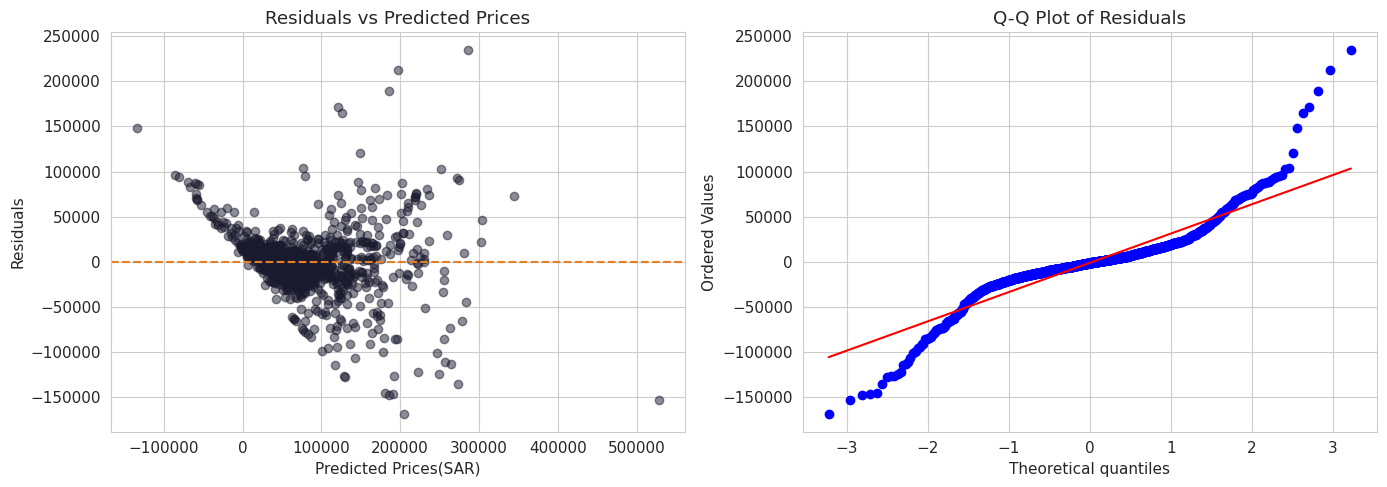

In [25]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted Prices (check for non-linearity, heteroscedasticity)
axes[0].scatter(y_pred_test, residuals, alpha=0.5, color="#1A1A2E")
axes[0].axhline(y=0, color="#E67E22", linestyle="--")
axes[0].set_xlabel("Predicted Prices(SAR)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Predicted Prices")

# Q-Q plot (check normality of residuals)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

### 6.3 Collinearity Check

In [26]:
# VIF was not calculated for all encoded variables because one-hot encoding created many dummy columns.
# Collinearity was checked using the correlation matrix instead.
# Year was removed from the final model because Car_Age was created from it.


In [6]:
import pandas as pd
import sklearn
import matplotlib
import seaborn as sns
import numpy as np

print("pandas", pd.__version__)
print("scikit-learn", sklearn.__version__)
print("matplotlib", matplotlib.__version__)
print("seaborn", sns.__version__)
print("numpy", np.__version__)

pandas 2.2.2
scikit-learn 1.6.1
matplotlib 3.10.0
seaborn 0.13.2
numpy 2.0.2
